# 딥러닝응용III — Lecture 02 실습
# BERT 감성 분류 파이프라인 (답안 포함)

| 항목 | 내용 |
|------|------|
| **강의** | 딥러닝응용III (자연어처리) |
| **수업** | 2주차 — 자연어처리 개요와 전이학습 |
| **전공** | 데이터사이언스전공, 동덕여자대학교 |
| **교수** | 유원상 교수 |
| **참고** | [ratsgo's NLPBOOK](https://ratsgo.github.io/nlpbook/docs/introduction/pipeline/) |

---

## 학습 목표

1. **전이학습(Transfer Learning)** 의 원리를 코드로 이해한다.
2. **프리트레인 → 파인튜닝** 파이프라인의 각 단계가 왜 필요한지 설명할 수 있다.
3. 토크나이저, 데이터 로더, 모델, 학습 루프의 역할과 관계를 파악한다.
4. 주요 하이퍼파라미터(learning_rate, batch_size, max_seq_length 등)의 의미를 안다.

## 실습 방법

| 아이콘 | 유형 | 설명 |
|--------|------|------|
| 📝 | 빈칸 채우기 | `______` 으로 표시된 코드 빈칸을 직접 채우세요 |
| ❓ | 개념 질문 | 마크다운 셀의 질문에 직접 답을 작성하세요 |
| 🐛 | 오류 수정 | 일부러 틀린 코드를 찾아 고치세요 |
| 🧮 | 계산 문제 | 주어진 값으로 직접 계산해 보세요 |

> 💡 **빈칸과 질문의 정답은 중간고사 범위입니다.**

## 실행 전 확인

1. 상단 메뉴 → **런타임 → 런타임 유형 변경 → GPU** 선택
2. **셀 1** 실행 → 재시작 팝업 뜨면 **[세션 다시 시작]** 클릭
3. 이후 **셀 2부터** 순서대로 실행

---

## 전체 파이프라인 개요

```
① 설정값 정의  →  ② 데이터 다운로드  →  ③ 프리트레인 모델 준비
      ↓
④ 토크나이저  →  ⑤ 데이터 로더  →  ⑥ 태스크 정의  →  ⑦ 학습
```

| 항목 | 내용 |
|------|------|
| **프리트레인 모델** | KcBERT (한국어 댓글로 사전학습된 BERT) |
| **파인튜닝 데이터** | NSMC (네이버 영화 감성 코퍼스, 긍정/부정 이진 분류) |
| **프레임워크** | PyTorch + HuggingFace Transformers + PyTorch Lightning |

---

## 셀 1. 환경 설치 및 소스 패치

> 최초 1회만 실행합니다.

`ratsnlp`는 이기창 저자가 교재 실습용으로 만든 파이썬 패키지입니다. Python 3.7 시절에 만들어져서 현재 Colab(Python 3.12)과 호환되지 않기 때문에, 아래와 같은 우회 전략을 사용합니다:

1. `pip install ratsnlp` 대신 **`git clone`** 으로 소스코드를 직접 가져옵니다.
2. 호환되지 않는 부분을 **패치(patch)** 합니다 — 파일 안의 특정 문자열을 찾아 바꿉니다.

| 문제 | 원인 | 해결 |
|------|------|------|
| PyYAML 빌드 실패 | Python 3.12 비호환 | `PyYAML>=6.0` 선설치 |
| `AdamW` import 오류 | transformers 4.36+에서 제거됨 | `torch.optim.AdamW`로 교체 |
| `gpus=` 파라미터 오류 | pytorch-lightning 2.x API 변경 | `accelerator=`/`devices=` 사용 |

> 이 셀은 환경 설정이므로, 개념적으로 이해하되 코드를 외울 필요는 없습니다.

In [ ]:
import os

os.system('pip install -q "tokenizers>=0.19.0" --prefer-binary')
os.system('pip install -q "transformers>=4.36.0" "pytorch-lightning>=1.9.0" "PyYAML>=6.0" Korpora flask flask-ngrok flask-cors')

if not os.path.exists('/content/ratsnlp'):
    os.system('git clone -q https://github.com/ratsgo/ratsnlp.git /content/ratsnlp')
    print('ratsnlp 클론 완료')
else:
    print('ratsnlp 이미 존재')

patches = [
    [None, 'from transformers.optimization import AdamW', 'from torch.optim import AdamW'],
    ['/content/ratsnlp/ratsnlp/nlpbook/classification/corpus.py',
     '        [(example.text_a, example.text_b) for example in examples],',
     '        [example.text_a if example.text_b is None else (example.text_a, example.text_b) for example in examples],'],
    ['/content/ratsnlp/ratsnlp/nlpbook/trainer.py',
     '        gpus=torch.cuda.device_count() if torch.cuda.is_available() else None,\n        precision=16 if args.fp16 else 32,\n        # For TPU Setup\n        tpu_cores=args.tpu_cores if args.tpu_cores else None,',
     '        accelerator="gpu" if torch.cuda.is_available() else "cpu",\n        devices=torch.cuda.device_count() if torch.cuda.is_available() else 1,\n        precision=16 if args.fp16 else 32,'],
    ['/content/ratsnlp/ratsnlp/nlpbook/trainer.py', 'train_dataloader=', 'train_dataloaders='],
]

for fpath, old, new in patches:
    if fpath is None:
        for root, dirs, files in os.walk('/content/ratsnlp'):
            for fname in files:
                if not fname.endswith('.py'): continue
                fp = os.path.join(root, fname)
                src = open(fp, 'r', encoding='utf-8').read()
                if old in src:
                    open(fp, 'w', encoding='utf-8').write(src.replace(old, new))
                    print(f'  패치: {fp}')
    else:
        src = open(fpath, 'r', encoding='utf-8').read()
        if old in src:
            open(fpath, 'w', encoding='utf-8').write(src.replace(old, new))
            print(f'  패치: {fpath}')
        else:
            print(f'  불필요: {fpath}')

print('\n✅ 완료! 런타임 재시작 팝업이 뜨면 [세션 다시 시작]을 클릭하세요.')

ratsnlp 클론 완료
  패치: /content/ratsnlp/ratsnlp/nlpbook/classification/task.py
  패치: /content/ratsnlp/ratsnlp/nlpbook/generation/task.py
  패치: /content/ratsnlp/ratsnlp/nlpbook/qa/task.py
  패치: /content/ratsnlp/ratsnlp/nlpbook/ner/task.py
  패치: /content/ratsnlp/ratsnlp/nlpbook/classification/corpus.py
  패치: /content/ratsnlp/ratsnlp/nlpbook/trainer.py
  불필요: /content/ratsnlp/ratsnlp/nlpbook/trainer.py

✅ 완료! 런타임 재시작 팝업이 뜨면 [세션 다시 시작]을 클릭하세요.


---

## 셀 2. ratsnlp 경로 등록

> **런타임 재시작 후 이 셀부터 실행합니다.**

Python이 `import ratsnlp`를 실행하면, **`sys.path`에 등록된 폴더들을 순서대로 뒤져서** 모듈을 찾습니다. git clone으로 가져온 ratsnlp는 시스템 패키지 경로에 없으므로, 수동으로 추가해야 합니다.

#### 주요 메서드 비교

| 메서드 | 동작 | 효과 |
|--------|------|------|
| `sys.path.insert(0, 경로)` | 리스트 **맨 앞**에 삽입 | 가장 먼저 검색됨 (우선순위 최상) |
| `sys.path.append(경로)` | 리스트 **맨 뒤**에 추가 | 나중에 검색됨 (우선순위 최하) |

### ❓ Q2-1. `sys.path.insert(0, ...)` vs `sys.path.append(...)`

**🔑 답:** `0`은 리스트의 0번째(맨 앞) 위치에 삽입하라는 의미. 가장 먼저 검색되므로 패치된 버전이 우선 사용됨. `append`를 쓰면 시스템에 다른 버전이 있을 경우 패치 안 된 버전이 먼저 import될 수 있음.

In [ ]:
import sys
# sys.path: Python이 모듈을 탐색하는 경로 리스트
# insert(0, ...): 맨 앞에 삽입 → 최우선 탐색
if '/content/ratsnlp' not in sys.path:
    sys.path.insert(0, '/content/ratsnlp')

# ClassificationTrainArguments: 학습에 필요한 모든 설정값을 담는 데이터 클래스
from ratsnlp.nlpbook.classification import ClassificationTrainArguments
print('✅ ratsnlp 로드 성공')

✅ ratsnlp 로드 성공


---

## 셀 3. Google Drive 연결

Colab의 런타임은 **임시 가상 머신(VM)** 입니다. 세션이 끊기면 `/content/` 아래의 모든 파일이 삭제됩니다. 모델의 **체크포인트(checkpoint)** — 학습 도중 모델 가중치를 `.ckpt` 파일로 저장한 것 — 를 Google Drive에 보존해야 합니다.

### ❓ Q3-1. 체크포인트의 필요성

**🔑 답:** 3시간 학습한 모델 가중치가 전부 삭제되어, 처음부터 다시 학습해야 합니다. 체크포인트가 있으면 마지막 저장 시점부터 이어서 학습(resume) 가능.

In [ ]:
from google.colab import drive
# drive.mount(): Google Drive를 Colab 파일 시스템에 연결
# force_remount=True: 이미 마운트되어 있어도 강제 재연결
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


---

## 셀 4. 설정값 정하기 (하이퍼파라미터 설정)

**하이퍼파라미터(hyperparameter)**: 학습 알고리즘의 동작 방식을 제어하는 설정값. **사람이 직접 정해주는 값**이며, 모델이 데이터로부터 학습하는 파라미터(가중치)와 구분됩니다.

| 파라미터 | 값 | 의미 |
|----------|-----|------|
| `pretrained_model_name` | `"beomi/kcbert-base"` | HuggingFace Hub의 프리트레인 모델 ID. 한국어 댓글 9GB로 사전학습된 BERT |
| `downstream_corpus_name` | `"nsmc"` | 파인튜닝용 데이터셋. Naver Sentiment Movie Corpus |
| `downstream_corpus_root_dir` | `"/content/Korpora"` | 다운로드된 데이터 저장 경로 |
| `downstream_model_dir` | Drive 내 경로 | 체크포인트 저장 경로 (Drive에 저장해야 세션 종료 후에도 유지) |
| `learning_rate` | `5e-5` | 한 스텝에서 가중치 업데이트 크기. BERT 논문 권장: **1e-5 ~ 5e-5** |
| `batch_size` | `32` | 한 번에 모델에 입력하는 샘플 수 |

#### learning_rate의 역할 — 학습의 보폭

| 값 | 현상 |
|-----|------|
| 너무 큼 (예: 0.1) | 최적점을 지나쳐 Loss 발산. 프리트레인 지식 파괴 (catastrophic forgetting) |
| 너무 작음 (예: 1e-8) | 수렴이 너무 느려 시간 내에 좋은 성능 못 얻음 |
| 적절 (예: 5e-5) | Loss가 안정적으로 감소하여 최적점에 수렴 |

### ❓ Q4-1. learning_rate 이해

**🔑 답:** (a) `5×10⁻⁵` = **0.00005** (b) `1e-4` = 0.0001 > `5e-5` = 0.00005 이므로 **1e-4가 2배 더 큼**

### ❓ Q4-2. learning_rate가 너무 크면?

**🔑 답:** 가중치가 너무 크게 업데이트되어 Loss가 발산(oscillation)하고, 프리트레인에서 학습한 언어 지식이 파괴됨 (catastrophic forgetting). 0.1은 권장 범위(1e-5~5e-5)보다 약 2,000배 큰 값.

### 🧮 Q4-3. 배치 수 계산

**🔑 답:** (a) **4,688** (b) **2,344** (c) **9,375**. batch_size를 반으로 줄이면 스텝 수가 2배.

### 🧮 Q4-4. 총 스텝 수 계산

**🔑 답:** 4,688 × 3 = **14,064 스텝**

### 📝 Q4-5. 빈칸 채우기 — 설정값 코드 (정답 포함)

In [ ]:
from ratsnlp.nlpbook.classification import ClassificationTrainArguments

args = ClassificationTrainArguments(
    pretrained_model_name="beomi/kcbert-base",
    downstream_corpus_name="nsmc",
    downstream_corpus_root_dir="/content/Korpora",
    downstream_model_dir="/gdrive/My Drive/nlpbook/checkpoint-cls",
    learning_rate=5e-5,   # 🔑 정답: 5e-5
    batch_size=32,        # 🔑 정답: 32
)

print('✅ 설정값 확인')
print(f'  pretrained_model_name : {args.pretrained_model_name}')
print(f'  downstream_corpus_name: {args.downstream_corpus_name}')
print(f'  learning_rate         : {args.learning_rate}')
print(f'  batch_size            : {args.batch_size}')
print(f'  max_seq_length        : {args.max_seq_length}')
print(f'  epochs                : {args.epochs}')

✅ 설정값 확인
  pretrained_model_name : beomi/kcbert-base
  downstream_corpus_name: nsmc
  learning_rate         : 5e-05
  batch_size            : 32
  max_seq_length        : 128
  epochs                : 3


### ❓ Q4-6. max_seq_length의 의미

**🔑 답:** (a) 입력 시퀀스의 **최대 토큰 수**. 이보다 긴 문장은 잘림(truncation). (b) 128개 토큰까지만 사용하고 나머지는 **잘라버림(truncation)**. (c) 장점: 긴 문장 처리 가능. 단점: GPU 메모리 사용 증가, 학습 속도 저하.

---

## 셀 5. 데이터 내려받기

**NSMC(Naver Sentiment Movie Corpus)**: 박은정 님이 공개한 한국어 감성 분류 벤치마크 데이터셋.

| 구분 | 파일 | 샘플 수 | 용도 |
|------|------|---------|------|
| 학습 | `ratings_train.txt` | 150,000개 | 모델 학습 |
| 평가 | `ratings_test.txt` | 50,000개 | 성능 평가 |

각 샘플의 컬럼: `id` (리뷰 고유번호), `document` (리뷰 텍스트), `label` (0=부정, 1=긍정)

이것이 우리의 **다운스트림 태스크** 데이터입니다.

### ❓ Q5-1. 데이터 이해

**🔑 답:** (a) NSMC는 중립을 제외한 **이진 분류**(긍정/부정 2개). `num_labels=2`. (b) 학습 데이터로 평가 = 이미 본 시험 문제로 시험 보는 것. 모델이 새 데이터에 대한 **일반화 능력**을 측정할 수 없고, 과적합 여부를 판단 불가.

### ❓ Q5-2. 지도 학습 vs 자기지도 학습

**🔑 답:** (a) **지도 학습**. 사람이 만든 정답 레이블(0/1)이 있음. (b) **자기지도 학습**. 사람이 레이블을 달지 않고, 텍스트 자체에서 빈칸을 만들어 정답으로 사용. 대규모 데이터를 저비용으로 활용 가능.

In [ ]:
from Korpora import Korpora
# Korpora: 한국어 말뭉치를 쉽게 다운로드하는 패키지
# fetch(): 지정된 코퍼스를 다운로드하여 root_dir에 저장

Korpora.fetch(
    corpus_name=args.downstream_corpus_name,   # "nsmc"
    root_dir=args.downstream_corpus_root_dir,  # "/content/Korpora"
    force_download=True,  # 이미 있어도 재다운로드
)

# 다운로드된 데이터 확인
import csv
with open('/content/Korpora/nsmc/ratings_train.txt', 'r', encoding='utf-8') as f:
    rows = list(csv.reader(f, delimiter='\t'))

print(f'\n✅ 다운로드 완료')
print(f'  컬럼: {rows[0]}')            # ['id', 'document', 'label']
print(f'  학습 샘플 수: {len(rows)-1:,}개')  # 150,000
print(f'\n  샘플 예시:')
for r in rows[1:6]:
    label_str = "긍정" if r[2] == "1" else "부정"
    print(f'    [{label_str}] {r[1][:50]}')

[nsmc] download ratings_train.txt: 14.6MB [00:00, 128MB/s]                            
[nsmc] download ratings_test.txt: 4.90MB [00:00, 54.2MB/s]



✅ 다운로드 완료
  컬럼: ['id', 'document', 'label']
  학습 샘플 수: 150,000개

  샘플 예시:
    [부정] 아 더빙.. 진짜 짜증나네요 목소리
    [긍정] 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
    [부정] 너무재밓었다그래서보는것을추천한다
    [부정] 교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
    [긍정] 사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가


### ❓ Q5-3. 코드 독해

**🔑 답:** `rows[0]`이 **헤더(컬럼명) 행**이기 때문. 실제 데이터는 `rows[1]`부터 시작하므로, 데이터 수 = 전체 행 수 - 1.

---

## 셀 6. 프리트레인 모델 준비하기 ⭐

이 셀은 **전이학습의 핵심**입니다.

### 전이학습(Transfer Learning)의 원리

```
[업스트림 태스크: 프리트레인]              [다운스트림 태스크: 파인튜닝]
KcBERT는 9GB 한국어 댓글 텍스트로   →   NSMC 150K 샘플로
"빈칸 채우기(MLM)"를 수행하며             "긍정 vs 부정" 분류를 학습
한국어의 일반적 문맥을 이해               이미 배운 언어 지식을 재활용!
```

### 코드에서 사용하는 핵심 클래스

| 클래스 | 역할 | 비유 |
|--------|------|------|
| `BertConfig` | 모델의 **설계도** (레이어 수, 히든 크기 등) | 건물 청사진 |
| `BertForSequenceClassification` | BERT 본체 + 분류 헤드 | 건물 + 옥상 안테나 |
| `from_pretrained()` | 학습된 가중치를 HuggingFace Hub에서 다운로드 | 이미 지어진 건물 가져오기 |

### 모델 구조 도식

```
입력 토큰 IDs → [BERT 본체: 12층 Transformer] → [CLS] 벡터 (768차원)
                                                       ↓
                                              [분류 헤드: Linear(768, 2)]
                                                       ↓
                                              logits: [긍정점수, 부정점수]
```

> 이것이 강의에서 배운 **"프리트레인을 마친 마스크 언어 모델(노란색) 위에 작은 모듈(초록색)을 쌓는 것"** 입니다!

### ❓ Q6-1. 전이학습 개념

**🔑 답:** (a) 긍정/부정 **이진 분류**이므로 `2`. 3클래스면 `num_labels=3`. (b) **마스크 언어 모델(MLM, Masked Language Model)**. 이 학습 과정을 **프리트레인(pretrain)** 이라 함. (c) **다음 단어 맞추기 (Language Model)** — 앞 문맥만 보고 다음 단어를 예측.

### ❓ Q6-2. 프리트레인의 가치

**🔑 답:** 약 1억 개 파라미터를 15만 개 데이터만으로 학습해야 하므로 데이터가 절대적으로 부족. 프리트레인으로 이미 학습된 언어 지식(문법, 의미, 문맥)이 없어 성능이 현저히 낮고 수렴에 훨씬 오래 걸림. 전이학습은 대규모 데이터에서 배운 일반적 언어 능력을 재활용하는 것.

### 📝 Q6-3. 빈칸 채우기 — 모델 생성 코드 (정답 포함)

In [ ]:
from transformers import BertConfig, BertForSequenceClassification

pretrained_model_config = BertConfig.from_pretrained(
    args.pretrained_model_name,
    num_labels=2,   # 🔑 정답: 2 (긍정/부정 이진 분류)
)

model = BertForSequenceClassification.from_pretrained(
    args.pretrained_model_name,
    config=pretrained_model_config,
)

print(f'✅ 모델 준비 완료: {args.pretrained_model_name}')
print(f'  hidden_size       : {pretrained_model_config.hidden_size}')
print(f'  num_hidden_layers : {pretrained_model_config.num_hidden_layers}')
print(f'  num_attention_heads: {pretrained_model_config.num_attention_heads}')
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  전체 파라미터      : {total:,}')
print(f'  학습 가능 파라미터 : {trainable:,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ 모델 준비 완료: beomi/kcbert-base
  hidden_size       : 768
  num_hidden_layers : 12
  num_attention_heads: 12
  전체 파라미터      : 108,920,066
  학습 가능 파라미터 : 108,920,066


### 🧮 Q6-4. 분류 헤드 파라미터 수 계산

**🔑 답:** (a) W shape = **(2 × 768)** (b) b shape = **(2)** (c) 2×768 + 2 = 1536 + 2 = **1,538개**

### ❓ Q6-5. p.numel()과 p.requires_grad 이해

**🔑 답:** `p.numel()`은 텐서의 **원소 수**(number of elements). 전자는 모델의 **전체** 파라미터 수, 후자는 `requires_grad=True`인 **학습 가능한** 파라미터 수만 셈. 보통 파인튜닝에서는 모든 파라미터가 학습 가능이므로 두 값이 같음.

### 🐛 Q6-6. 오류 수정 — 모델 생성

**🔑 답:**
1. `num_labels=3` → `num_labels=2` (NSMC는 이진 분류)
2. `"klue/bert-base"` → `"beomi/kcbert-base"` (config와 model은 같은 모델 사용해야 함)

---

## 셀 7. 토크나이저 준비하기 ⭐

딥러닝 모델은 **숫자(텐서)** 만 입력받을 수 있습니다. 자연어 문장을 숫자로 변환하는 과정이 **토큰화(Tokenization)** 입니다.

### 토큰화의 3단계

```
"짜증나네요"  →  ["짜증", "##나", "##네", "##요"]  →  [15231, 2483, 2102, 2259]
    문장            WordPiece 토큰화                     어휘사전(vocab) 인덱싱
```

### BERT 특수 토큰

| 토큰 | 의미 | 역할 |
|------|------|------|
| `[CLS]` | Classification | 문장의 시작. 이 위치의 출력 벡터가 **문장 전체의 의미**를 요약 |
| `[SEP]` | Separator | 문장의 끝. 두 문장 입력 시 구분자 역할도 함 |
| `[PAD]` | Padding | 짧은 문장 뒤에 채워 길이를 맞추는 역할 |
| `##` 접두사 | 서브워드 | 앞 토큰에 이어지는 조각 (WordPiece의 특징) |

### 주요 메서드

| 메서드 | 입력 → 출력 | 설명 |
|--------|-----------|------|
| `tokenizer.tokenize(text)` | 문자열 → 토큰 리스트 | `"짜증나네요"` → `["짜증", "##나", "##네", "##요"]` |
| `tokenizer.encode(text)` | 문자열 → 정수 ID 리스트 | `"안녕"` → `[2, 5765, 3]` (특수 토큰 포함 시) |
| `tokenizer.vocab_size` | — → 정수 | 어휘사전에 등록된 전체 토큰 수 |

### ❓ Q7-1. 특수 토큰의 역할

**🔑 답:** (a) BERT의 Self-Attention에서 문장 전체 정보가 `[CLS]` 위치에 종합됨. 분류 헤드는 이 768차원 벡터를 입력받아 분류 수행. (b) 문장의 끝을 표시. 자연어 추론(NLI)처럼 두 문장 입력 시 문장 구분자 역할. (c) 서브워드 접두사. 독립 단어가 아닌, **앞 토큰에 이어지는 조각**임을 표시. WordPiece 알고리즘의 특징.

### ❓ Q7-2. encode 결과 해석

**🔑 답:** (a) `[CLS]`의 ID (b) `[SEP]`의 ID (c) `[5765]` — 특수 토큰 없이 실제 토큰만 반환

### ❓ Q7-3. 토크나이저와 모델의 관계

**🔑 답:** 프리트레인 시 사용된 어휘사전(vocab)과 동일한 것을 써야 함. 다른 토크나이저를 사용하면 같은 단어가 전혀 다른 ID로 변환되어, 프리트레인된 가중치와 입력 토큰 간의 매핑이 깨져 모델이 제대로 동작하지 않음.

In [ ]:
from transformers import BertTokenizer
# BertTokenizer: BERT 모델 전용 토크나이저
# from_pretrained(): 프리트레인 모델과 동일한 어휘사전(vocab)을 다운로드
# do_lower_case: True이면 입력을 소문자로 변환. 한국어에는 대소문자가 없으므로 False

tokenizer = BertTokenizer.from_pretrained(
    args.pretrained_model_name,   # "beomi/kcbert-base" — 반드시 모델과 동일!
    do_lower_case=False,          # 한국어이므로 소문자 변환 불필요
)

print('✅ 토크나이저 준비 완료')
print(f'  어휘사전(vocab) 크기: {tokenizer.vocab_size:,}개')

# 토큰화 과정을 직접 확인
examples = [
    '아 더빙.. 진짜 짜증나네요 목소리',
    '완전 재밌었어요!! 강력 추천합니다',
    '별로였어요 시간 낭비',
]
print()
for sent in examples:
    tokens = tokenizer.tokenize(sent)     # 문장 → 토큰 리스트 (특수 토큰 없음)
    ids    = tokenizer.encode(sent, add_special_tokens=True)  # 문장 → [CLS] + IDs + [SEP]
    print(f'  입력 문장  : {sent}')
    print(f'  토큰 리스트: {tokens}')
    print(f'  토큰 IDs  : {ids}')
    print(f'  [CLS]={ids[0]}, [SEP]={ids[-1]}')
    print()

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ 토크나이저 준비 완료
  어휘사전(vocab) 크기: 30,000개

  입력 문장  : 아 더빙.. 진짜 짜증나네요 목소리
  토큰 리스트: ['아', '더', '##빙', '.', '.', '진짜', '짜증나네', '##요', '목소리']
  토큰 IDs  : [2, 2170, 832, 5045, 17, 17, 7992, 29734, 4040, 10720, 3]
  [CLS]=2, [SEP]=3

  입력 문장  : 완전 재밌었어요!! 강력 추천합니다
  토큰 리스트: ['완전', '재밌', '##었어요', '!', '!', '강력', '추천', '##합니다']
  토큰 IDs  : [2, 8357, 13365, 16849, 5, 5, 9523, 11030, 8063, 3]
  [CLS]=2, [SEP]=3

  입력 문장  : 별로였어요 시간 낭비
  토큰 리스트: ['별로', '##였어', '##요', '시간', '낭비']
  토큰 IDs  : [2, 10515, 13198, 4040, 8485, 12861, 3]
  [CLS]=2, [SEP]=3



### 🧮 Q7-4. 토큰 수 세기

**🔑 답:** (실행 결과에 따라 다르지만 일반적으로) (a) 토큰 리스트의 원소 수 (b) 토큰 수 + 2 (CLS, SEP 추가) (c) 항상 **2개** 차이. `encode(add_special_tokens=True)`가 앞에 [CLS], 뒤에 [SEP]를 추가하기 때문.

### 🐛 Q7-5. 오류 수정 — 토크나이저 코드

**🔑 답:**

| # | 오류 | 수정 | 이유 |
|---|------|------|------|
| 1 | `"klue/bert-base"` | `"beomi/kcbert-base"` | 모델과 동일한 토크나이저 필수 |
| 2 | `do_lower_case=True` | `False` | 한국어에는 대소문자 없음 |
| 3 | `add_special_tokens=False` | `True` | BERT 입력에 [CLS], [SEP] 필수 |

### ❓ Q7-6. do_lower_case 이해

**🔑 답:** (a) 입력 텍스트를 소문자로 변환 ("Hello" → "hello"). (b) `uncased` 모델은 대소문자를 구분하지 않고 프리트레인되었으므로, 추론 시에도 소문자로 통일해야 어휘사전과 매칭됨.

---

## 셀 8. 데이터 로더 준비하기

### 데이터가 모델에 들어가기까지의 흐름

```
NsmcCorpus (파일 읽기)
  ↓  ratings_train.txt의 15만 줄을 읽어옴
ClassificationDataset (토큰화 + 변환)
  ↓  각 문장을 토큰 ID, attention mask, label로 변환
DataLoader (배치 구성)
  ↓  32개씩 묶어서 텐서 형태로 학습 루프에 공급
```

### 핵심 개념

| 개념 | 설명 |
|------|------|
| **배치(Batch)** | GPU 병렬 처리를 위해 샘플을 `batch_size`개씩 묶음 |
| **패딩(Padding)** | 배치 안의 문장 길이를 맞추기 위해 `[PAD]`(ID=0)으로 채움 |
| **Attention Mask** | 실제 토큰=1, 패딩=0으로 표시. 모델이 패딩을 무시하도록 함 |
| **token_type_ids** | 문장 A=0, 문장 B=1로 구분 (단문장 분류에서는 전부 0) |

```
input_ids      : [2, 15231, 2483, 2102, 3, 0, 0, 0]
attention_mask : [1,     1,    1,    1, 1, 0, 0, 0]
                  ↑ 실제 토큰 = 1          ↑ PAD = 0
```

### 주요 클래스

| 클래스 | 역할 |
|--------|------|
| `NsmcCorpus` | NSMC 파일을 읽어 (text, label) 쌍으로 반환 |
| `ClassificationDataset` | 각 문장을 토크나이저로 변환하여 텐서로 만듦 |
| `DataLoader` | Dataset에서 batch_size개씩 꺼내 묶어줌 |
| `RandomSampler` | 매 에포크마다 데이터를 **무작위로 섞음** (학습용) |
| `collate_fn` | 길이가 다른 시퀀스를 **패딩하여 통일**하는 함수 |

### ❓ Q8-1. 배치와 패딩

**🔑 답:** (a) GPU는 병렬 연산에 최적화. 1개씩 넣으면 GPU 연산 능력을 낭비. 배치로 묶으면 행렬 연산으로 동시에 처리하여 효율적. (b) 한 배치 안의 문장들은 길이가 다르지만, 텐서(행렬)로 묶으려면 **같은 차원**이어야 함. 짧은 문장 뒤에 [PAD]를 채워 길이를 맞춤.

### ❓ Q8-2. Attention Mask

**🔑 답:** (a) `1` = 실제 토큰 → attention 계산에 포함. `0` = 패딩 토큰 → attention에서 제외. (b) [PAD] 토큰에도 attention이 적용되어 의미 없는 정보가 다른 토큰에 영향을 미침. 모델 성능 저하.

### ❓ Q8-3. 샘플러 비교

**🔑 답:** (a) 순서대로 넣으면 비슷한 샘플이 연속 학습되어 편향(bias) 발생, 과적합 위험 증가. 무작위로 섞으면 매 에포크마다 다양한 배치 조합으로 일반화 성능 향상. (b) 평가는 결과의 **재현성**이 중요. 순서를 섞으면 매번 다른 결과가 나올 수 있어 비교 어려움.

### 📝 Q8-4. 빈칸 채우기 — DataLoader 코드 (정답 포함)

In [ ]:
from torch.utils.data import DataLoader, RandomSampler
from ratsnlp.nlpbook.classification.corpus import NsmcCorpus, ClassificationDataset
from ratsnlp import nlpbook

corpus = NsmcCorpus()

train_dataset = ClassificationDataset(
    args=args, corpus=corpus, tokenizer=tokenizer,
    mode="train",     # 🔑 정답: "train"
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=args.batch_size,
    sampler=RandomSampler(train_dataset, replacement=False),  # 🔑 정답: RandomSampler
    collate_fn=nlpbook.data_collator,
    drop_last=False,
    num_workers=args.cpu_workers,
)

sample_batch = next(iter(train_dataloader))
print('✅ 데이터 로더 준비 완료')
print(f'  학습 샘플 수  : {len(train_dataset):,}개')
print(f'  배치 크기     : {args.batch_size}')
print(f'  전체 배치 수  : {len(train_dataloader):,}개')
print(f'\n  배치 텐서 구조:')
for k, v in sample_batch.items():
    print(f'    {k:20s}: shape={list(v.shape)}, dtype={v.dtype}')

✅ 데이터 로더 준비 완료
  학습 샘플 수  : 150,000개
  배치 크기     : 32
  전체 배치 수  : 4,688개

  배치 텐서 구조:
    labels              : shape=[32], dtype=torch.int64
    input_ids           : shape=[32, 128], dtype=torch.int64
    attention_mask      : shape=[32, 128], dtype=torch.int64
    token_type_ids      : shape=[32, 128], dtype=torch.int64


### 🧮 Q8-5. 텐서 shape 해석

**🔑 답:** (a) **batch_size** (한 배치의 샘플 수) (b) 해당 배치에서 **가장 긴 문장의 토큰 수** (다른 문장은 이 길이까지 패딩) (c) **[32, 39]** — input_ids와 동일 (각 토큰이 실제/패딩인지 표시) (d) **[32]** — 1차원. 각 샘플의 정답 레이블 1개(0 또는 1)만 필요.

### 🐛 Q8-6. 오류 수정 — DataLoader

**🔑 답:**

| # | 오류 | 수정 | 이유 |
|---|------|------|------|
| 1 | `SequentialSampler` | `RandomSampler` | **학습** 데이터는 무작위로 섞어야 과적합 방지 |
| 2 | `drop_last=True` | `drop_last=False` | True면 마지막 불완전 배치의 데이터가 버려짐 |

---

## 셀 9. 태스크 정의하기

`ClassificationTask`는 PyTorch Lightning의 `LightningModule`을 상속받은 클래스로, **모델 + 옵티마이저 + 학습 로직**을 하나로 묶습니다.

### 학습 1스텝의 흐름 (매우 중요! ⭐)

```
① 배치 입력 (input_ids, attention_mask, labels)
     ↓
② BERT 인코딩 → 각 토큰의 768차원 벡터 생성
     ↓
③ [CLS] 벡터를 분류 헤드(Linear(768,2))에 통과 → logits (2차원 점수)
     ↓
④ CrossEntropyLoss(logits, labels) → 손실(loss) 값 계산
     ↓
⑤ loss.backward() → 역전파(backpropagation)로 그래디언트 계산
     ↓
⑥ optimizer.step() → 그래디언트 방향으로 가중치 업데이트
```

이것이 강의에서 배운 **"출력이 정답에 가까워지도록 모델을 업데이트하는 과정"** 입니다.

### 주요 구성 요소

| 구성 요소 | 역할 |
|----------|------|
| `model` | BertForSequenceClassification — 예측값(logits) 생성 |
| `optimizer` (AdamW) | 가중치를 어떤 방향으로, 얼마나 업데이트할지 결정 |
| `scheduler` (ExponentialLR) | 학습이 진행될수록 learning_rate를 점진적으로 줄임 |
| `training_step()` | 위 ①~④를 수행 (⑤~⑥은 Lightning이 자동 처리) |

### ❓ Q9-1. Loss의 의미

**🔑 답:** (a) 모델의 예측이 정답에 **점점 가까워짐** — 학습이 잘 진행 중 (b) **과적합(overfitting)** — 학습 데이터에만 맞춰지고 새 데이터에 대한 일반화 능력 저하 (c) learning_rate가 너무 작거나 모델에 문제가 있을 수 있음

### ❓ Q9-2. optimizer와 scheduler

**🔑 답:** (a) 계산된 그래디언트를 사용하여 **가중치를 어떤 방향으로, 얼마나 업데이트할지** 결정하는 알고리즘 (b) 학습 초반에는 큰 보폭으로 빠르게 수렴하고, 후반에는 작은 보폭으로 미세 조정하여 최적점을 지나치지 않도록 함.

### 📝 Q9-3. 학습 흐름 빈칸 채우기

**🔑 답:** ② **768** ③ **logits** ④ **CrossEntropyLoss** ⑤ **backward** ⑥ **step**

In [ ]:
from ratsnlp.nlpbook.classification import ClassificationTask
# ClassificationTask: LightningModule 상속
#   - model: BertForSequenceClassification (우리가 전달)
#   - configure_optimizers(): AdamW + ExponentialLR 설정
#   - training_step(batch): 순전파 + Loss 계산 (역전파는 Lightning이 자동 처리)

task = ClassificationTask(model, args)

print('✅ 태스크 정의 완료')
print(f'  모델 클래스 : {type(task.model).__name__}')
print(f'  epochs     : {args.epochs}')

✅ 태스크 정의 완료
  모델 클래스 : BertForSequenceClassification
  epochs     : 3


---

## 셀 10. 모델 학습하기

PyTorch Lightning의 `Trainer`가 아래 학습 루프를 자동 실행합니다:

```python
for epoch in range(epochs):              # 에포크 반복
    for batch in train_dataloader:       # 배치 반복
        loss = task.training_step(batch) # 순전파 + 손실 계산
        loss.backward()                  # 역전파 (그래디언트 계산)
        optimizer.step()                 # 가중치 업데이트
        optimizer.zero_grad()            # 그래디언트 초기화
```

### 모니터링 포인트

| 지표 | 의미 | 좋은 신호 |
|------|------|----------|
| Train Loss | 학습 데이터에 대한 손실 | 우하향 (지속적 감소) |
| Val Loss | 검증 데이터에 대한 손실 | Train Loss와 함께 감소 |
| Accuracy | 정확도 | 지속적 증가 |

> 이 셀의 코드는 길고 복잡합니다. **Trainer가 하는 일의 전체 흐름**을 이해하는 것이 중요합니다.

### ❓ Q10-1. 학습 결과 해석

**🔑 답:** (a) 4,688 × 3 = **14,064번** (b) **과적합(overfitting)**. 해결: ① Early Stopping, ② Dropout 조정, ③ 데이터 증강, ④ 정규화 등 (c) `eval()`: Dropout 비활성화, BatchNorm 고정 (평가 모드). `train()`: Dropout 활성화, BatchNorm 학습 모드.

### ❓ Q10-2. torch.no_grad()의 역할

**🔑 답:** 그래디언트 계산을 OFF. 검증은 가중치를 업데이트하지 않으므로 그래디언트가 불필요. 이를 끄면 **메모리 절약 + 속도 향상**.

  [모델 & 학습 설정]
  모델: beomi/kcbert-base
  파라미터: 108,920,066 (108.9M)
  데이터: 150,000개 | 배치 32 | 에포크당 4,688스텝
  학습: 3ep | 총 14,064스텝 | LR 5e-05
  시간제한: 최대 0:10
  GPU: Tesla T4

----------------------------------------------------------------
  ⏳ 학습 중
----------------------------------------------------------------
  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.7%  |  스텝 100/14,064  |  에포크 0/3
  경과: 1분22초
  [Train] Loss:0.2339 Acc:93.8%
----------------------------------------------------------------



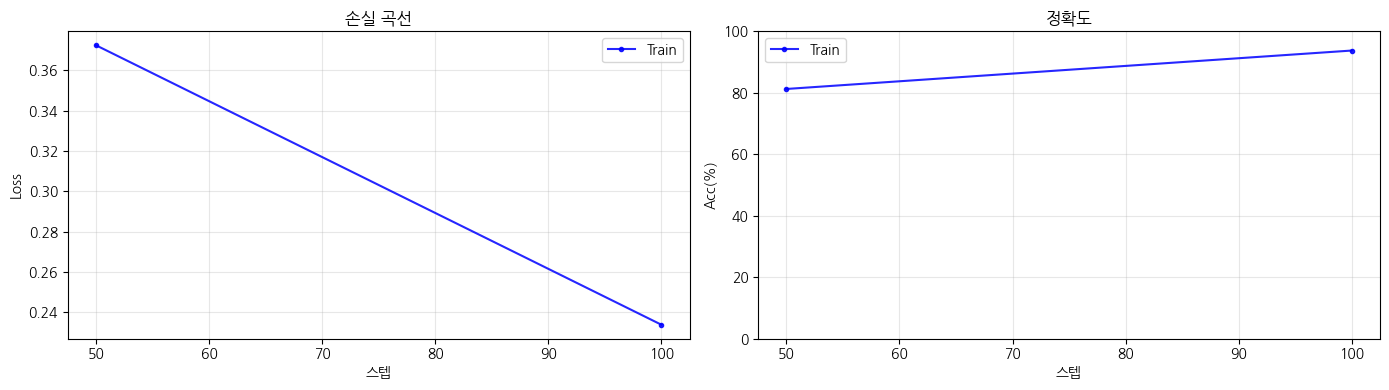

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [ ]:
import os, time, math, glob
import torch
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torch.utils.data import DataLoader, SequentialSampler, Subset
from IPython.display import clear_output, display, Javascript
import random

# ── 한국어 폰트 ──
os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

MAX_TRAIN_TIME = "0:10"

display(Javascript('''
if (window._keepAliveTimer) clearInterval(window._keepAliveTimer);
window._keepAliveTimer = setInterval(function() {
  var btn = document.querySelector("colab-toolbar-button#connect");
  if (btn) btn.click();
}, 60000);
'''))
print('Keep-alive ON\n')

from ratsnlp.nlpbook.classification.corpus import NsmcCorpus, ClassificationDataset
val_dataset = ClassificationDataset(args=args, corpus=NsmcCorpus(), tokenizer=tokenizer, mode='test')
random.seed(42)
val_indices = random.sample(range(len(val_dataset)), min(1000, len(val_dataset)))
val_sub = Subset(val_dataset, val_indices)
val_loader = DataLoader(val_sub, batch_size=64, sampler=SequentialSampler(val_sub),
    collate_fn=nlpbook.data_collator, num_workers=args.cpu_workers)
print(f'Validation 서브셋: {len(val_sub):,}개\n')

def run_validation(pl_module):
    pl_module.eval()
    tot_loss, tot_ok, tot_n = 0.0, 0, 0
    with torch.no_grad():
        for vb in val_loader:
            inp = vb['input_ids'].to(pl_module.device)
            attn = vb.get('attention_mask')
            ttype = vb.get('token_type_ids')
            lbl = vb['labels'].to(pl_module.device)
            if attn is not None: attn = attn.to(pl_module.device)
            if ttype is not None: ttype = ttype.to(pl_module.device)
            out = pl_module.model(input_ids=inp, attention_mask=attn,
                                  token_type_ids=ttype, labels=lbl)
            tot_loss += out.loss.item() * len(lbl)
            tot_ok += (out.logits.argmax(-1) == lbl).sum().item()
            tot_n += len(lbl)
    pl_module.train()
    return tot_loss / tot_n, tot_ok / tot_n

def build_info_str(model, args, dl, max_time):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    spe = len(dl)
    time_str = f'최대 {max_time}' if max_time else '제한 없음'
    lines = ['='*64, '  [모델 & 학습 설정]', '='*64,
        f'  모델: {args.pretrained_model_name}',
        f'  파라미터: {total:,} ({total/1e6:.1f}M)',
        f'  데이터: {len(dl.dataset):,}개 | 배치 {args.batch_size} | 에포크당 {spe:,}스텝',
        f'  학습: {args.epochs}ep | 총 {spe*args.epochs:,}스텝 | LR {args.learning_rate}',
        f'  시간제한: {time_str}']
    if torch.cuda.is_available():
        lines.append(f'  GPU: {torch.cuda.get_device_name(0)}')
    lines.append('='*64)
    return '\n'.join(lines)

class TrainingMonitorCallback(pl.Callback):
    def __init__(self, info_str, total_epochs, spe, plot_every=50, val_every=200):
        self.info_str=info_str; self.total_epochs=total_epochs; self.spe=spe
        self.total_steps=total_epochs*spe; self.plot_every=plot_every; self.val_every=val_every
        self.step_count=0; self.cur_epoch=0; self.t0=None
        self.tr_steps=[]; self.tr_losses=[]; self.tr_accs=[]
        self.vl_steps=[]; self.vl_losses=[]; self.vl_accs=[]
    def on_train_start(self, trainer, pl_module): self.t0=time.time()
    def on_epoch_start(self, trainer, pl_module): self.cur_epoch=trainer.current_epoch+1
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        loss = outputs['loss'].item() if isinstance(outputs,dict) else float(outputs)
        try:
            with torch.no_grad():
                inp=batch['input_ids'].to(pl_module.device)
                attn=batch.get('attention_mask'); tt=batch.get('token_type_ids')
                lbl=batch['labels'].to(pl_module.device)
                if attn is not None: attn=attn.to(pl_module.device)
                if tt is not None: tt=tt.to(pl_module.device)
                out=pl_module.model(input_ids=inp,attention_mask=attn,token_type_ids=tt)
                acc=(out.logits.argmax(-1)==lbl).float().mean().item()
        except: acc=float('nan')
        self.step_count+=1
        if self.step_count%self.val_every==0:
            vl,va=run_validation(pl_module); self.vl_steps.append(self.step_count)
            self.vl_losses.append(vl); self.vl_accs.append(va)
        if self.step_count%self.plot_every==0:
            self.tr_steps.append(self.step_count); self.tr_losses.append(loss); self.tr_accs.append(acc)
            self._render(loss,acc,False)
    def on_train_end(self, trainer, pl_module):
        vl,va=run_validation(pl_module); self.vl_steps.append(self.step_count)
        self.vl_losses.append(vl); self.vl_accs.append(va)
        self._render(self.tr_losses[-1] if self.tr_losses else 0, self.tr_accs[-1] if self.tr_accs else 0, True)
    def _render(self, cur_loss, cur_acc, final):
        elapsed=time.time()-self.t0; progress=self.step_count/self.total_steps if self.total_steps else 0
        eta=int((elapsed/progress-elapsed)) if progress>0.01 else 0
        bar='█'*int(30*progress)+'░'*(30-int(30*progress))
        clear_output(wait=True); print(self.info_str); print()
        status='✅ 완료' if final else '⏳ 학습 중'
        print(f'{"-"*64}\n  {status}\n{"-"*64}')
        print(f'  [{bar}] {progress*100:.1f}%  |  스텝 {self.step_count:,}/{self.total_steps:,}  |  에포크 {self.cur_epoch}/{self.total_epochs}')
        el_m,el_s=divmod(int(elapsed),60); print(f'  경과: {el_m}분{el_s}초', end='')
        if not final and progress>0.01: eta_m,eta_s=divmod(eta,60); print(f'  잔여: {eta_m}분{eta_s}초',end='')
        print(f'\n  [Train] Loss:{cur_loss:.4f}'+(' Acc:{:.1f}%'.format(cur_acc*100) if cur_acc==cur_acc else ''))
        if self.vl_losses: print(f'  [Val]   Loss:{self.vl_losses[-1]:.4f} Acc:{self.vl_accs[-1]*100:.1f}%')
        print(f'{"-"*64}\n')
        fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,4))
        ax1.plot(self.tr_steps,self.tr_losses,'b-o',ms=3,lw=1.5,label='Train',alpha=.85)
        if self.vl_steps: ax1.plot(self.vl_steps,self.vl_losses,'r-s',ms=5,lw=2,label='Val')
        ax1.set_xlabel('스텝'); ax1.set_ylabel('Loss'); ax1.set_title('손실 곡선',fontweight='bold'); ax1.grid(True,alpha=.3); ax1.legend()
        cl=[(s,a*100) for s,a in zip(self.tr_steps,self.tr_accs) if a==a]
        if cl: ts,ta=zip(*cl); ax2.plot(ts,ta,'b-o',ms=3,lw=1.5,label='Train',alpha=.85)
        if self.vl_steps: ax2.plot(self.vl_steps,[a*100 for a in self.vl_accs],'r-s',ms=5,lw=2,label='Val')
        ax2.set_xlabel('스텝'); ax2.set_ylabel('Acc(%)'); ax2.set_ylim(0,100); ax2.set_title('정확도',fontweight='bold'); ax2.grid(True,alpha=.3); ax2.legend()
        plt.tight_layout()
        if final: plt.savefig('/content/training_curve.png',dpi=150,bbox_inches='tight')
        plt.show()

ckpt_dir=args.downstream_model_dir; os.makedirs(ckpt_dir,exist_ok=True)
ckpt_files=sorted(glob.glob(os.path.join(ckpt_dir,'step-*.ckpt')))
resume_ckpt=ckpt_files[-1] if ckpt_files else None
print(f'이어받기: {os.path.basename(resume_ckpt)}' if resume_ckpt else '새 학습 시작')
step_ckpt=ModelCheckpoint(dirpath=ckpt_dir,filename='step-{step:06d}',every_n_train_steps=200,save_top_k=1,monitor=None)
best_ckpt=ModelCheckpoint(dirpath=ckpt_dir,save_top_k=args.save_top_k,monitor=args.monitor.split()[1],mode=args.monitor.split()[0],filename='{epoch}-{val_loss:.2f}')

from datetime import timedelta
def parse_max_time(s):
    if s is None: return None
    p=s.split(':')
    if len(p)==2: return timedelta(hours=int(p[0]),minutes=int(p[1]))
    if len(p)==3: return timedelta(hours=int(p[0]),minutes=int(p[1]),seconds=int(p[2]))
max_td=parse_max_time(MAX_TRAIN_TIME)
if max_td: h,r=divmod(int(max_td.total_seconds()),3600); m,s=divmod(r,60); print(f'시간제한: {h}h{m}m{s}s\n')
else: print('시간제한: 없음\n')
spe=len(train_dataloader); info_str=build_info_str(model,args,train_dataloader,MAX_TRAIN_TIME)
print(info_str); print()
monitor=TrainingMonitorCallback(info_str=info_str,total_epochs=args.epochs,spe=spe,plot_every=50,val_every=200)
trainer=Trainer(max_epochs=args.epochs,max_time=max_td,fast_dev_run=args.test_mode,
    num_sanity_val_steps=0,callbacks=[best_ckpt,step_ckpt,monitor],default_root_dir=ckpt_dir,
    enable_progress_bar=False,enable_model_summary=False,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=torch.cuda.device_count() if torch.cuda.is_available() else 1,
    precision=16 if args.fp16 else 32,
    deterministic=torch.cuda.is_available() and args.seed is not None)
trainer.fit(task,train_dataloaders=train_dataloader,ckpt_path=resume_ckpt)

---

## 셀 11. 학습 결과 확인

학습 완료 후 Google Drive에 체크포인트(`.ckpt`)가 저장됩니다. 이 파일에 학습된 모델의 모든 가중치가 들어 있습니다.

In [ ]:
import os

checkpoint_dir = args.downstream_model_dir
if os.path.exists(checkpoint_dir):
    files = [f for f in os.listdir(checkpoint_dir) if not f.endswith('.lock')]
    print(f'✅ 저장된 체크포인트 ({checkpoint_dir}):')
    for f in sorted(files):
        size = os.path.getsize(os.path.join(checkpoint_dir, f))
        print(f'  {f}  ({size/1024/1024:.1f} MB)')
else:
    print('체크포인트 디렉터리가 없습니다.')

✅ 저장된 체크포인트 (/gdrive/My Drive/nlpbook/checkpoint-cls):
  lightning_logs  (0.0 MB)
  step-step=000400.ckpt  (1246.7 MB)


---
---

# 📝 종합 퀴즈 (중간고사 대비)

아래 문제들은 이 실습 노트북에서 다룬 핵심 개념을 점검합니다.
중간고사의 코딩 문제는 이 문제들과 유사한 형식으로 출제됩니다.

---

### 퀴즈 1. 전이학습 용어 빈칸 채우기

**🔑 답:** 프리트레인(pretrain), 다운스트림(downstream), 파인튜닝(fine-tuning), 마스크 언어 모델(MLM) / 빈칸 채우기, 언어 모델(LM) / 다음 단어 예측

---

### 퀴즈 2. 코드 완성 — 모델 생성

**🔑 답:** (A) = `2` (이진 분류) (B) = `BertForSequenceClassification`

---

### 퀴즈 3. 오류 수정 — 토크나이저 (3개 오류)

**🔑 답:**

| # | 오류 | 수정 | 이유 |
|---|------|------|------|
| 1 | `"klue/bert-base"` | `"beomi/kcbert-base"` | 모델과 동일한 토크나이저 |
| 2 | `True` | `False` | 한국어에 대소문자 없음 |
| 3 | `False` | `True` | BERT 입력에 [CLS],[SEP] 필수 |

---

### 퀴즈 4. 특수 토큰 서술

**🔑 답:** (a) 문장 시작 토큰. Self-Attention에서 문장 전체 정보가 종합. 분류 헤드의 입력. (b) 문장의 끝 표시. 두 문장 입력 시 구분자. (c) 서브워드 접두사 — 앞 토큰에 이어지는 조각.

---

### 퀴즈 5. 배치 수 계산

**🔑 답:** (a) ceil(150000/64) = **2,344** (b) 2,344 × 2 = **4,688** (c) ceil(150000/32) = **4,688** (2배 증가)

---

### 퀴즈 6. 오류 수정 — DataLoader (2개 오류)

**🔑 답:** (1) `SequentialSampler` → `RandomSampler` (학습은 무작위) (2) `drop_last=True` → `False` (데이터 낭비 방지)

---

### 퀴즈 7. 개념 매칭

**🔑 답:** ① → **(C)** ② → **(A)** ③ → **(B)** ④ → **(D)**

---

### 퀴즈 8. 차원 계산 — 모델 출력

**🔑 답:** (a) `[32, 128, 768]` (b) `[32, 768]` (c) `[32, 2]`

---

### 퀴즈 9. 학습 1스텝 흐름

**🔑 답:** ② **768** ③ **logits** ④ **CrossEntropyLoss** ⑤ **backward** ⑥ **step**

---

### 퀴즈 10. 하이퍼파라미터 분석

**🔑 답:** (a) Loss 발산 + catastrophic forgetting (프리트레인 지식 파괴). 1e-3은 권장 범위보다 약 20~100배 큼. (b) 스텝 수: 18,750 (4배 증가). 배치가 작아 그래디언트 분산 커지고 불안정해질 수 있으나 더 세밀한 학습도 가능.

---

### 퀴즈 11. 추론 코드 완성

**🔑 답:** `'pt'` (PyTorch 텐서), `no_grad` (그래디언트 OFF), `argmax` (최대값 인덱스), `1` (1=긍정)

---

### 퀴즈 12. 다운스트림 태스크 비교

**🔑 답:**

| 태스크 | 입력 | 출력 |
|--------|------|------|
| 문서 분류 | 문장 1개 | **범주별 확률 (긍정/부정)** |
| 자연어 추론 | **문장 2개** | 참/거짓/중립 확률 |
| 개체명 인식 | 문장 1개 | **단어별 개체명 범주 확률** |
| 질의응답 | **질문 + 지문** | **정답의 시작/끝 위치 확률** |

---

### 퀴즈 13. 지도 학습 vs 자기지도 학습

**🔑 답:** (a) **지도 학습** — 사람이 부여한 정답 레이블(0/1) 사용. (b) **자기지도 학습** — 텍스트에서 자동으로 빈칸을 만들어 정답 생성. 레이블링 비용 없이 대규모 데이터 활용.

---

### 퀴즈 14. 코드 독해 — collate_fn

**🔑 답:** 배치 내 시퀀스들의 길이가 다르므로, `[PAD]` 토큰으로 채워 **같은 길이로 맞추고 텐서로 변환**하는 함수. 없으면 길이가 다른 리스트를 텐서로 변환하려 할 때 오류 발생.

---

### 퀴즈 15. 코드 완성 — 데이터 로더

**🔑 답:** (A) = `train` (B) = `RandomSampler`

---

> 🔑 **교수 참고**: 이 퀴즈의 난이도와 형식을 기준으로 중간고사 문제를 출제하시면 됩니다.